In [1]:
import geopandas as gpd
import rasterio
import os
import pandas as pd
import numpy as np
import pandapower as pp
import sys
import copy
import plotly.io as pio
import plotly.graph_objects as go
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from rasterstats import zonal_stats
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
from pandapower.plotting.plotly import pf_res_plotly

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from power_flow import build_pandapower_model

load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\zlib1.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\abseil_dll.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\utf8_validity.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\re2.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\libprotobuf.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\highs.dll...
load c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\ortools\.libs\ortools.dll...


In [2]:
# === Read power network data ===
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update_remove_disconnected.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')
gens_gdf = gpd.read_file('../outputs/plant_update.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')
trafo_gdf = gpd.read_file('../outputs/table_transformers.gpkg')

basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

tc_path = '../data/tc/tc_yagi.tif'
# flood_path = '../data/flood/'

In [3]:
loads_gdf.head()

,element_type,osmid,nodes,landuse,name,name:en,operator,owner,plant:method,plant:output:electricity,plant:source,power,wikidata,source,industrial,access,barrier,amenity,parking,access:conditional,building:levels,fence,material,addr:housenumber,addr:street,addr:street:en,addr:street:zh,building,bus,depot,name:zh,operator:type,ownership,ref,alt_name,building:part,building:part:levels,layer,official_name,official_name:en,official_name:zh,old_name,old_name:en,old_name:zh,government,motor_vehicle,operation,operator:en,operator:ownership,operator:wikidata,operator:zh,fence:material,fuel,man_made,measurement,pipeline,pumping_station,substance,substation,usage,addr:housename,addr:housename:en,addr:housename:zh,area,drinking_water,note:landuse,salt,utility,office,addr:suburb,addr:suburb:en,addr:suburb:zh,phone,website,reservoir:location,telecom,addr:borough,addr:borough:en,addr:borough:zh,temporary,cargo,designation,designation:en,designation:short_name,designation:short_name:en,designation:zh,port,short_name,short_name:en,was:landuse,ways,type,waste,wall,natural,brand,brand:en,brand:zh,demolished:amenity,demolished:end_date,demolished:name,demolished:name:en,demolished:name:zh,depot:service,network,network:en,network:zh,owner:en,owner:wikidata,owner:zh,proposed:landuse,hazard,was:end_date,was:name,was:name:en,was:name:zh,pumping_station:area,fire_station:type,product,product:wikidata,alt_name:en,alt_name:zh,fixme,fixme:name,fixme:name:en,fixme:name:zh,addr:city,wikipedia,operator:zh-Hans,operator:zh-Hant,brand:wikidata,not:amenity,police,addr:street:carriageway_ref:kmb,addr:street:direction:kmb,addr:street:ref:kmb,addr:street:wikidata,plant:output:cold_water,pipeline:inspection_gauge,addr:town,addr:town:en,addr:town:zh,description,industry,operator:short,operator:short:en,operator:short:zh,operator:short:zh-Hans,operator:short:zh-Hant,opened,name:zh-Hans,name:zh-Hant,not:man_made,water,owner:official_name,owner:official_name:zh,owner:official_name:zh-Hans,owner:official_name:zh-Hant,owner:ref,owner:short_name,owner:short_name:en,owner:short_name:zh,name:de,name:fr,name:nan,name:nan-HJ,name:nan-POJ,name:nan-TL,start_date,addr:country,addr:full,addr:place,addr:postcode,addr:province,not:substance,not:substance:wikidata,closing_date,description:en,description:zh,proposed:leisure,addr:district,proposed:amenity,proposed:description,proposed:description:en,proposed:description:zh,branch,branch:en,branch:zh,education,addr:town:wikidata,brand:zh-Hans,brand:zh-Hant,owner:zh-Hans,owner:zh-Hant,recycling_type,demolished:landcover,demolished:natural,operator:short_name,operator:short_name:en,operator:short_name:zh,short_name:zh,addr:city_block,addr:city_block:en,addr:city_block:zh,noname:zh,not:landuse,waterway,check_date,construction,demolished:anthropogenic,note,was:amenity,alt_name_1,fax,email,smoking,access:start_date,was:access,was:access:end_date,service,loc_name,loc_name:en,reg_name,reg_name:en,reg_name:zh,tourism,was:leisure,roof:levels,roof:shape,addr:quarter,addr:quarter:en,addr:quarter:zh,wastewater_plant,frequency,voltage,height,wikimedia_commons,fuel:JetA1,not:aeroway,name:yue,note:highway,mooring,brand:wikipedia,boundary,wall:height,int_name,name:zh_pinyin,abutters,commercial,retail,college,sewerage,content,demolished:water,demolished:source,was:parking,name:yue-Hant,location,plant:output:hot_water,fence_type,addr:plot,addr:plot:en,addr:plot:zh,proposed:demolished:landuse,proposed:demolished:man_made,proposed:residential,healthcare,operator:official_name,operator:official_name:en,operator:official_name:zh,operator:ref,demolished:landuse,disputed,informal,operator:owner,operator:owner:zh,drinking_water:access,addr:place:en,addr:place:zh,brand:ref,network:ref,network:wikidata,subway,hgv_articulated,trailer,addr:plot:loc_ref,proposed:name,proposed:name:en,proposed:name:zh,seamark:harbour:category,operator:wikipedia,website:en,website:zh,demolished:maintained,demolished:managed,fixme:highway,fixme:sport,loc_name:zh,residential,opening_d

In [111]:
hl2_df = trafo_gdf[trafo_gdf['name'].str.endswith('_hl2')]
hm3_df = trafo_gdf[trafo_gdf['name'].str.endswith('_hm3')]
ml3_df = trafo_gdf[trafo_gdf['name'].str.endswith('_ml3')]

In [112]:
print("Number of 500-220kV transformers: ", len(hl2_500_220_df) + len(hm3_df))
print("Number of 220-110kV transformers: ", len(hl2_220_110_df) + len(ml3_df))

Number of 500-220kV transformers:  59
Number of 220-110kV transformers:  151


In [114]:
# 步骤1：构建 NodeID 集合
node_ids = set(nodes_gdf["NodeID"].unique())

# 步骤2：判断 hv_bus 和 lv_bus 是否在 node_ids 中
hv_not_found = ~trafo_gdf["hv_bus"].isin(node_ids)
lv_not_found = ~trafo_gdf["lv_bus"].isin(node_ids)

# 步骤3：取出任一不匹配的行
invalid_trafo_rows = trafo_gdf[hv_not_found | lv_not_found]

# 输出结果
invalid_trafo_rows

,name,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,i0_percent,geometry,hv_bus_id,lv_bus_id
198,1198563264.0_hl2,NODEVN3653a,NODEVN3653b,1646.141088,220.0,110.0,12.0,0.7,30.0,0.15,POINT (678368.513 1230414.041),NaN,NaN
213,1263497515.0_hl2,NODEVN3732b,NODEVN3732a,731.618261,220.0,110.0,12.0,0.7,30.0,0.15,POINT (404438.673 2364530.738),NaN,NaN
219,1265274413.0_hl2,NODEVN3770a,NODEVN3770b,548.713696,220.0,110.0,12.0,0.7,30.0,0.15,POINT (693053.502 2321015.491),NaN,NaN


In [8]:
# === Read fragility curves ===
def load_curves(curve_path, sheet_name=None):
    # 先读取前5行用于获取正确的列名（ID number 行）
    raw = pd.read_excel(curve_path, sheet_name=sheet_name, nrows=5)
    
    # 用第1列为 index（即 'Wind speed (m/s)'），第2~n列为 curve ID
    id_row = raw.iloc[0, 1:]  # “ID number” 行，作为列名
    id_row.index = range(1, len(id_row)+1)

    # 读取真正的数据，从第6行开始
    df = pd.read_excel(curve_path, sheet_name=sheet_name, skiprows=5)

    # 将列名替换为 ['Wind speed', ID1, ID2, ...]
    df.columns = ['Wind speed'] + list(id_row)

    # 保证所有数值列都是 float
    df = df.apply(pd.to_numeric, errors='coerce')

    # design wind speed (dws)
    original_dws = 44
    target_dws = 60
    # shift design wind speed of all curves to 60 m/s
    scaling_factor = original_dws / target_dws
    df['Wind speed'] = df['Wind speed'] * scaling_factor

    # interpolate the curves to fill missing values
    df = df.interpolate()

    return df

In [4]:
curve_path = '../data/fragility_curves.xlsx'
curves = load_curves(curve_path, sheet_name='test') # wind_curves_test

curves.head()

,Wind speed,W1,W3.15,W3.45,W6.1,W6.2
0,0,0,0.000000e+00,0.0,0.000000e+00,0.0
1,1,0,0.000000e+00,0.0,1.250000e-16,0.0
2,2,0,3.549661e-278,0.0,1.326058e-13,0.0
3,3,0,4.069272e-221,0.0,7.806489e-12,0.0
4,4,0,1.242419e-184,0.0,1.406744e-10,0.0


In [9]:
curves = load_curves(curve_path, sheet_name='test') # wind_curves_test

curves.head()

,Wind speed,W1,W3.15,W3.45,W6.1,W6.2
0,0.000000,0,0.000000e+00,0.0,0.000000e+00,0.0
1,0.733333,0,0.000000e+00,0.0,1.250000e-16,0.0
2,1.466667,0,3.549661e-278,0.0,1.326058e-13,0.0
3,2.200000,0,4.069272e-221,0.0,7.806489e-12,0.0
4,2.933333,0,1.242419e-184,0.0,1.406744e-10,0.0


In [4]:
# # === Load wind speed map (geotiff) ===
# def load_tc(tif_path, speed_threshold=0):
#     with rasterio.open(tif_path) as src:
#         band1 = src.read(1)
#         mask = band1 > speed_threshold
#         transform = src.transform
#         geoms = (
#             shape(geom) for geom, val in shapes(band1, mask=mask, transform=transform)
#             if val > speed_threshold
#         )
#         gdf = gpd.GeoDataFrame(geometry=list(geoms), crs=src.crs)
#     return gdf.to_crs("EPSG:32648")

# # === Load flood extent (shapefile) ===
# def load_flood(folder_path):
#     all_shps = glob(os.path.join(folder_path, "*.shp"))
#     gdfs = [gpd.read_file(shp).to_crs("EPSG:32648") for shp in all_shps]
#     return gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

In [5]:
# tc_gdf = load_tc(tc_path)
# flood_gdf = load_flood(flood_path)

Min/Max wind raster value: 0.0 58.606785
--------------------
CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Width, Height: 121 111
Number of Bands: 1
Transform: | 0.10, 0.00, 102.95|
| 0.00,-0.10, 26.05|
| 0.00, 0.00, 1.00|
NoData Value: None
Band 1 shape: (111, 121)
Band 1 min: 0.0
Band 1 max: 58.606785
Band 1 mean: 6.845121


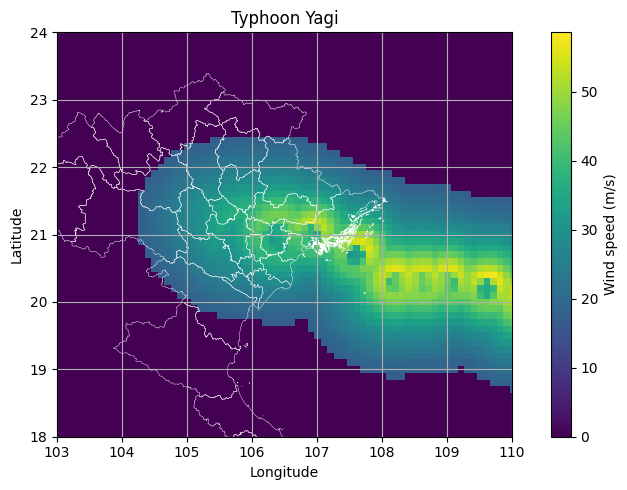

In [3]:
with rasterio.open(tc_path) as src:
    wind_speed = src.read(1)
    print("Min/Max wind raster value:", np.nanmin(wind_speed), np.nanmax(wind_speed))
    print("--------------------")

    transform = src.transform

    print("CRS:", src.crs)
    print("Width, Height:", src.width, src.height)
    print("Number of Bands:", src.count)
    print("Transform:", src.transform)
    print("NoData Value:", src.nodata)

    print("Band 1 shape:", wind_speed.shape)
    print("Band 1 min:", np.min(wind_speed))
    print("Band 1 max:", np.max(wind_speed))
    print("Band 1 mean:", np.mean(wind_speed))

    basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")
    basemap = basemap.to_crs("EPSG:4326")

    left = transform[2]
    top = transform[5]
    right = left + transform[0] * src.width
    bottom = top + transform[4] * src.height

    extent = (left, right, bottom, top)

    fig, ax = plt.subplots(figsize=(8, 5))
    img = ax.imshow(wind_speed, cmap="viridis", extent=extent, origin='upper')
    plt.colorbar(img, ax=ax, label="Wind speed (m/s)")
    basemap.plot(ax=ax, color='none', edgecolor='white', linewidth=0.3, zorder=1)

    ax.set_title("Typhoon Yagi")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(103, 110)
    ax.set_ylim(18, 24)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig("../figures/hazard_figures/yagi_map.png")
    plt.show()

In [6]:
def extract_point_wind_speed(gdf, src):
    """
        gdf: infrastructure vector data
        src: hazard map raster data
    """
    gdf = gdf.to_crs(src.crs)

    # 获取点的坐标
    coords = [(geom.x, geom.y) for geom in gdf.geometry]
    values = list(src.sample(coords))
    nodata = src.nodata

    # 提取风速值（注意处理nodata）
    wind_speeds = [v[0] if v[0] != nodata else 0 for v in values]
    gdf["wind_speed"] = wind_speeds
    return gdf

def extract_zonal_wind_speed(gdf, src, stats_method="max"):
    gdf = gdf.to_crs(src.crs)

    # 读取风速数据和transform信息
    wind_speed = src.read(1)
    transform = src.transform
    nodata = src.nodata

    # 处理 nodata
    if nodata is not None:
        wind_speed = np.where(wind_speed == nodata, 0, wind_speed)

    # 进行 zonal stats
    stats = zonal_stats(gdf, wind_speed, affine=transform, stats=stats_method)
    # print(stats[:5])

    gdf["wind_speed"] = [s[stats_method] if s[stats_method] is not None else 0 for s in stats]
    return gdf

In [7]:
def wind_speed_extraction(gdf, tif_path, stats_method="max"):
    with rasterio.open(tif_path) as src:
        results = []

        # 将不同类型的geometry分开处理
        print(gdf.geometry.geom_type.unique())
        for geom_type in gdf.geometry.geom_type.unique():
            sub_gdf = gdf[gdf.geometry.geom_type == geom_type].copy()

            if sub_gdf.empty:
                continue
            
            print(f"Processing {len(sub_gdf)} {geom_type}s...")
            
            sub_gdf = sub_gdf.to_crs(src.crs)

            if geom_type == "Point":
                sub_gdf = extract_point_wind_speed(sub_gdf, src)
            elif geom_type in ["LineString", "MultiLineString", "Polygon", "MultiPolygon"]:
                sub_gdf = extract_zonal_wind_speed(sub_gdf, src, stats_method=stats_method)
            else:
                print(f"Unsupported geometry type: {geom_type}, skipping...")
                continue

            results.append(sub_gdf)

        # 合并所有结果
        if results:
            return pd.concat(results, ignore_index=True)
        else:
            raise ValueError("No supported geometries found.")

In [8]:
lines_gdf_wind = wind_speed_extraction(lines_gdf, tc_path)
nodes_gdf_wind = wind_speed_extraction(nodes_gdf, tc_path)

['LineString']
Processing 6799 LineStrings...


c:\Users\mye500\AppData\Local\anaconda3\envs\py311\Lib\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


['Point']
Processing 3692 Points...


In [9]:
# nodes_gdf['substation'] = nodes_gdf['OriginalID'].astype(int) > 99999
# nodes_gdf.head()

In [10]:
def monte_carlo_simulation(gdf, curves, dam_class, num_iterations=2):
    """
        gdf: the geodataframe containing the asset data
        curves: fragility curves DataFrame containing failure probabilities
        dam_class: can be 'Bus' or 'Line' to specify asset type
        num_iterations: number of Monte Carlo simulations
    """
    
    # Filter real substations from buses (substations + virtual buses)
    # Ensure that the substation column exists and is initialized
    if dam_class == 'Bus' and 'substation' not in gdf.columns:
        # If 'substation' column does not exist, create it based on the OriginalID
        gdf['substation'] = gdf['OriginalID'].astype(int) > 99999

    simulation_result = gdf.copy()

    # 每次迭代创建新的 failure 列
    for iteration in range(num_iterations):
        fail_column = f'fail_iter_{iteration+1}'
        failures = []

        for i in range(len(simulation_result)):
            row = simulation_result.iloc[i]
            wind_speed = row['wind_speed']

            # === Choose fragility curve ID ===
            if dam_class == 'Line':
                if row['voltage'] == 110.0:
                    curve_id = 'W6.1'
                elif row['voltage'] in [220.0, 500.0]:
                    curve_id = 'W6.2'
                else:
                    raise ValueError(f"Unsupported voltage for Line: {row['voltage']}")

            elif dam_class == 'Bus':
                if row['substation'] == True:
                    curve_id = 'W1'
                else:
                    if row['voltage'] in [110.0, 220.0]:
                        curve_id = 'W3.15'
                    elif row['voltage'] == 500.0:
                        curve_id = 'W3.45'
                    else:
                        raise ValueError(f"Unsupported voltage for Bus: {row['voltage']}")
            else:
                raise ValueError(f"Unsupported dam_class: {dam_class}")

            # === 插值并抽样 ===
            frag_curve = curves[["Wind speed", curve_id]]
            interp_func = interp1d(frag_curve["Wind speed"], frag_curve[curve_id], kind='linear', fill_value='extrapolate')
            fail_prob = interp_func(wind_speed)
            rand_num = np.random.uniform(0, 1)
            failures.append(1 if rand_num <= fail_prob else 0)

        simulation_result[fail_column] = failures

    return simulation_result

lines_gdf_sim = monte_carlo_simulation(lines_gdf_wind, curves, 'Line', num_iterations=2)
nodes_gdf_sim = monte_carlo_simulation(nodes_gdf_wind, curves, 'Bus', num_iterations=2)

In [13]:
nodes_gdf_sim.head()

,NodeID,voltage,lon,lat,OriginalID,line_counts,sn_mva,disconnected,geometry,wind_speed,substation,fail_iter_1,fail_iter_2
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,153608703.0,8,2194.854783,no,POINT (106.06478 20.93373),40.603729,True,0,0
1,NODEVN0003a,220.0,682154.017051,2.315888e+06,4.0,12,3292.282175,no,POINT (106.75171 20.93445),39.775883,False,0,0
2,NODEVN3273a,110.0,684889.726446,2.304274e+06,241065371.0,7,2011.950218,no,POINT (106.77678 20.82928),40.078110,True,0,0
3,NODEVN3273b,220.0,684710.914392,2.304283e+06,241065371.0,7,2011.950218,no,POINT (106.77506 20.82938),40.078110,True,0,0
4,NODEVN3308,220.0,810022.256590,1.417833e+06,400413519.0,2,731.618261,no,POINT (107.85566 12.80995),0.000000,True,0,0


In [139]:
def plot_combined_failure_probability_map(lines_gdf, nodes_gdf, basemap, output_path=None):
    lines_gdf = lines_gdf.to_crs("EPSG:4326")
    nodes_gdf = nodes_gdf.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    # 区域筛选
    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    cmap = cm.Reds
    norm = colors.Normalize(vmin=0, vmax=1)

    # 自动计算 failure_probability（若未计算）
    for df in [lines_gdf, nodes_gdf]:
        fail_cols = [col for col in df.columns if col.startswith('fail_iter_')]
        if 'failure_probability' not in df.columns:
            df['failure_probability'] = df[fail_cols].mean(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(19, 7), constrained_layout=True)
    titles = ["Line Failure Probability", "Bus Failure Probability"]
    gdfs = [lines_gdf, nodes_gdf]

    for ax, gdf, title in zip(axes, gdfs, titles):
        failed = gdf[gdf['failure_probability'] > 0]
        non_failed = gdf[gdf['failure_probability'] == 0]

        ax.set_title(title, fontsize=16)
        ax.set_xlim(105, 107.5)
        ax.set_ylim(19.85, 21.7)
        ax.set_xlabel("Longitude", fontsize=15)
        if ax == axes[0]:
            ax.set_ylabel("Latitude", fontsize=15)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)
        # ax.set_aspect('auto')
        ax.tick_params(axis='both', which='major', labelsize=15)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
        other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)

        if gdf.geometry.iloc[0].geom_type == 'Point':
            if not non_failed.empty:
                ax.scatter(non_failed.geometry.x, non_failed.geometry.y,
                           s=8, color='lightgreen', alpha=0.5, label='Failure p = 0', zorder=2)
            if not failed.empty:
                ax.scatter(failed.geometry.x, failed.geometry.y,
                           s=failed['failure_probability'] * 10,
                           c=failed['failure_probability'],
                           cmap=cmap, norm=norm, alpha=0.8, zorder=3)
        elif gdf.geometry.iloc[0].geom_type == 'LineString':
            if not non_failed.empty:
                non_failed.plot(ax=ax, color='lightgreen', linewidth=0.8, zorder=2, alpha=0.5, label='Failure p = 0')
            if not failed.empty:
                failed.plot(ax=ax, column='failure_probability',
                            cmap=cmap, norm=norm, linewidth=1.5, zorder=3)

        ax.legend(loc='lower right', fontsize=16)
    
    # Set colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=axes, orientation="vertical", location='right', fraction=0.02, pad=0.0, aspect=30)
    cbar.set_label("Failure Probability", fontsize=15)
    cbar.ax.tick_params(labelsize=15)

    if output_path:
        plt.savefig(output_path, dpi=600, bbox_inches="tight")
        print(f"✓ Saved to: {output_path}")

    plt.show()


✓ Saved to: ../figures/hazard_figures/failure_probability_combined.png


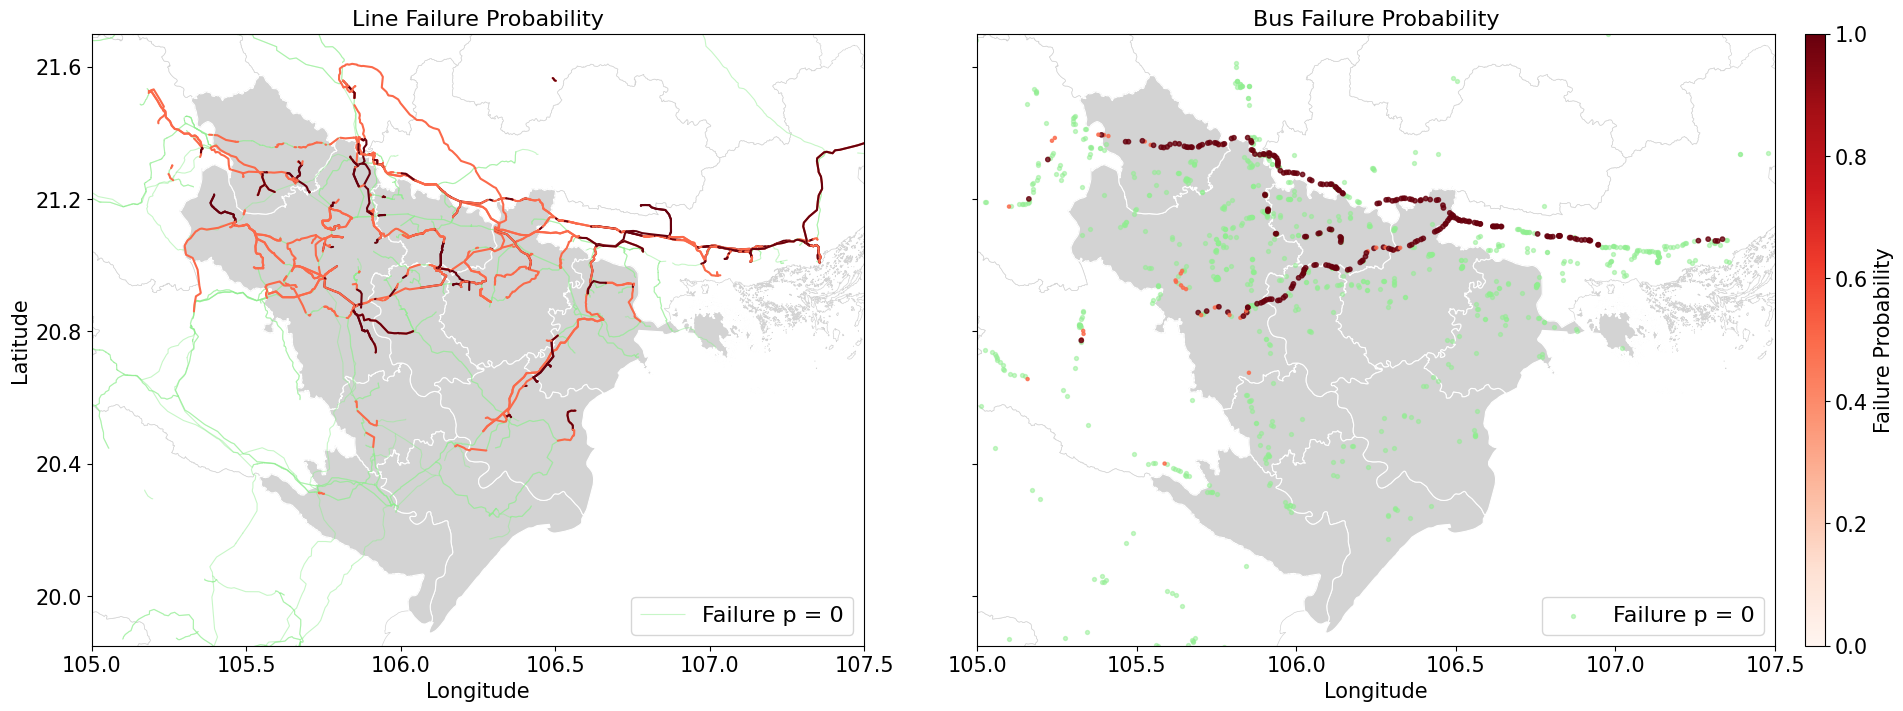

In [140]:
plot_combined_failure_probability_map(
    lines_gdf_sim,
    nodes_gdf_sim,
    basemap,
    output_path="../figures/hazard_figures/failure_probability_combined.png"
)

In [ ]:
# # OLD VERSION

# def plot_failure_probability_map(simulation_results, basemap, output_path=None):
#     simulation_results = simulation_results.to_crs("EPSG:4326")
#     basemap = basemap.to_crs("EPSG:4326")

#     # Define target regions to show on the map
#     pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
#     target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
#     other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

#     # 计算 failure_probability（如果还没算）
#     fail_cols = [col for col in simulation_results.columns if col.startswith('fail_iter_')]
#     if 'failure_probability' not in simulation_results.columns:
#         simulation_results['failure_probability'] = simulation_results[fail_cols].mean(axis=1)

#     failed = simulation_results[simulation_results['failure_probability'] > 0]
#     non_failed = simulation_results[simulation_results['failure_probability'] == 0]

#     cmap = cm.Reds
#     norm = colors.Normalize(vmin=0, vmax=1)

#     fig, ax = plt.subplots(figsize=(8,6))

#     # ax.set_title("Failure Probability - Red River Delta", fontsize=15)
#     ax.set_xlim(105.2, 107.6)
#     ax.set_ylim(19.85, 21.7)
#     ax.set_xlabel("Longitude", fontsize=12)
#     ax.set_ylabel("Latitude", fontsize=12)
#     ax.set_aspect('auto')
#     ax.tick_params(axis='both', which='major', labelsize=10)
#     ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
#     ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

#     # 叠加背景地图
#     target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
#     other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)

#     # 判断是否为点数据，若是点数据，使用 scatter
#     if simulation_results.geometry.iloc[0].geom_type == 'Point':  # 点数据
#         # 绘制 failure_probability == 0 的点（灰色底图）
#         if not non_failed.empty:
#             ax.scatter(non_failed.geometry.x, non_failed.geometry.y, 
#                        s=non_failed['failure_probability'].apply(lambda x: max(x * 100, 10)),  # 设置最小点大小
#                        c='lightgreen',  # 固定颜色
#                        alpha=0.5,  # 设置透明度
#                        zorder=2, label='Failure p = 0')

#         # 绘制 failure_probability > 0 的点（渐变色）
#         if not failed.empty:
#             ax.scatter(failed.geometry.x, failed.geometry.y, 
#                        s=failed['failure_probability'] * 10,  # 控制点的大小
#                        c=failed['failure_probability'],  # 设置颜色映射
#                        cmap=cmap, 
#                        norm=norm,
#                        alpha=0.7,  # 设置透明度
#                        zorder=3)
    
#     # 如果是线数据，使用 plot
#     elif simulation_results.geometry.iloc[0].geom_type == 'LineString':  # 线数据
#         # 绘制 failure_probability == 0 的线路（灰色底图）
#         if not non_failed.empty:
#             non_failed.plot(ax=ax, color='lightgreen', linewidth=0.4, zorder=2, alpha=0.5, label='Failure p = 0')

#         # 绘制 failure_probability > 0 的线路（渐变色）
#         if not failed.empty:
#             failed.plot(ax=ax,
#                         column='failure_probability',
#                         cmap=cmap,
#                         norm=norm,
#                         linewidth=1.3,
#                         zorder=3)

#     # 添加共享 colorbar
#     sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#     sm._A = []
#     cbar = fig.colorbar(sm, ax=ax, orientation="vertical", location='right', fraction=0.07, pad=0.04, aspect=20)
#     cbar.set_label("Failure probability", fontsize=12)

#     if output_path:
#         plt.savefig(output_path, dpi=600, bbox_inches="tight")
#         print(f"Saved to {output_path}")
    
#     plt.show()

Saved to ../figures/hazard_figures/failure_probability_map_lines.png


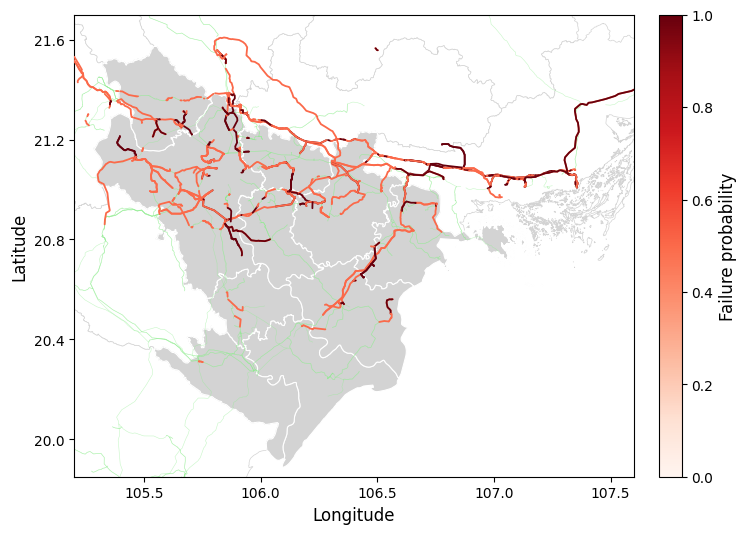

In [ ]:
# plot_failure_probability_map(lines_gdf_sim, basemap, output_path="../figures/hazard_figures/failure_probability_map_lines.png")

Saved to ../figures/hazard_figures/failure_probability_map_nodes.png


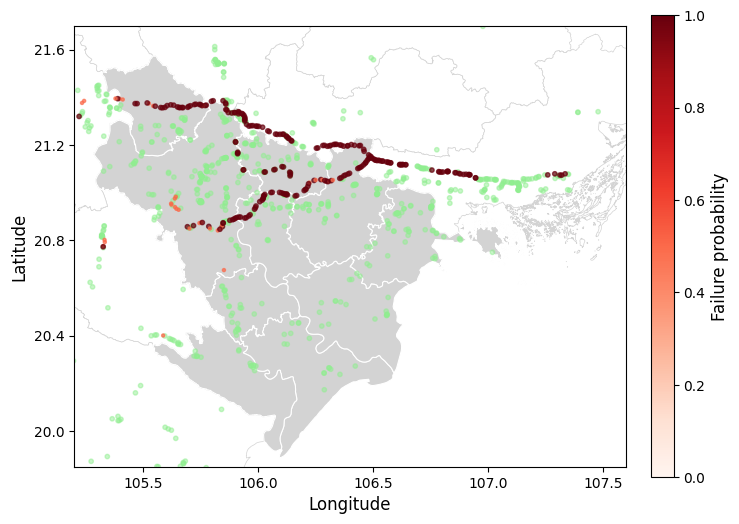

In [ ]:
# plot_failure_probability_map(nodes_gdf_sim, basemap, output_path="../figures/hazard_figures/failure_probability_map_nodes.png")

In [16]:
print(nodes_gdf_sim['fail_iter_2'].value_counts())

fail_iter_2
0    3450
1     242
Name: count, dtype: int64


In [14]:
def simulate_power_flows_over_failures(nodes_gdf_sim, lines_gdf_sim, gens_gdf, loads_gdf, trafo_gdf,
                                       num_iteration=2, use_column_in_service=True, outputh_path=None):
    base_net = build_pandapower_model(nodes_gdf_sim, lines_gdf_sim, gens_gdf, loads_gdf, trafo_gdf, use_column_in_service)

    results = []
    load_status_records = []
    failed_buses_records = []
    failed_lines_records = []
    overloaded_lines_records = []

    # 遍历所有 fail_iter_ 列
    # fail_columns = [col for col in lines_gdf_sim.columns if col.startswith('fail_iter')]

    for i in tqdm(range(num_iteration), desc="Simulating failure iterations"):
        print(f"Running simulation for: fail_iter_{i+1}")
        net = copy.deepcopy(base_net)

        # 反转 fail_iter_X 赋值：0 -> True, 1 -> False
        net.line['in_service'] = (lines_gdf_sim[f"fail_iter_{i+1}"] == 0)  # 0 表示 True (正常工作)，1 表示 False (失效)
        net.bus['in_service'] = (nodes_gdf_sim[f"fail_iter_{i+1}"] == 0)  # 0 表示 True (正常工作)，1 表示 False (失效)
        

        # 记录哪些bus被移除了
        failed_buses = net.bus[net.bus['in_service'] == False].index.tolist()
        for fb in failed_buses:
            failed_buses_records.append({
                "fail_iter": f"fail_iter_{i+1}",
                "bus_index": fb,
                "bus_name": net.bus.loc[fb, 'name']
            })

        # 随机失效的线路（基于bus失效）
        failed_lines_mask = ~net.bus.loc[net.line["from_bus"], "in_service"].values | \
                            ~net.bus.loc[net.line["to_bus"], "in_service"].values
        net.line.loc[failed_lines_mask, "in_service"] = False

        for idx in net.line[failed_lines_mask].index:
            line = net.line.loc[idx]
            failed_lines_records.append({
                "fail_iter": f"fail_iter_{i+1}",
                "line_name": line['name'],
                "from_bus": line["from_bus"],
                "to_bus": line["to_bus"]
            })

        try:
            pp.runpp(net)
            success = True
            print(f"✓ Power flow successful for {i+1}")
        except Exception as e:
            success = False
            print(f"✗ Power flow failed for {i+1}: {e}")
            continue

        if success:
            pp.to_excel(net, os.path.join(outputh_path, f"net_results_fail_iter{i+1}.xlsx"))
            voltages = net.res_bus.vm_pu[net.bus.in_service]
            under = sum(voltages < 0.95)
            over = sum(voltages > 1.05)
            voltage_violations = under + over

            total_load = net.load.p_mw.sum()
            total_supplied = net.res_load.p_mw.sum()
            load_served_ratio = total_supplied / total_load if total_load > 0 else np.nan

            overload_lines = net.res_line[(net.res_line.loading_percent > 100) & net.line["in_service"]]
            for idx, row in overload_lines.iterrows():
                overloaded_lines_records.append({
                    "fail_iter": f"fail_iter_{i+1}",
                    "line_index": idx,
                    "line_name": net.line.at[idx, "name"],
                    "loading_percent": row["loading_percent"]
                })

            overload_lines_count = len(overload_lines)
            overload_lines_ratio = overload_lines_count / net.line.in_service.sum() if net.line.in_service.sum() > 0 else 0

            for idx, row in net.load.iterrows():
                load_bus = row["bus"]
                is_served = (
                    net.bus.at[load_bus, "in_service"]
                    and not np.isnan(net.res_load.at[idx, "p_mw"])
                    and net.res_load.at[idx, "p_mw"] > 0
                )
                load_status_records.append({
                    "fail_iter": f"fail_iter_{i+1}",
                    "load_id": net.load.at[idx, "name"],
                    "bus": load_bus,
                    "served": is_served
                })


            # # 绘图并保存
            # fig_pf = pf_res_plotly(net, cmap='Jet', projection='epsg:4326', line_width=0.5, bus_size=5)
            # pio.write_html(fig_pf,
            #                file=os.path.join(outputh_path, f"Network_pf_fail_iter{i+1}.html"),
            #                auto_open=False, include_plotlyjs='cdn')

            # fig_pf_img = go.Figure(data=fig_pf.data)
            # fig_pf_img.update_layout(
            #     width=800,
            #     height=600,
            #     title=f"Power flow results (Failure Iteration {i+1})",
            #     margin=dict(l=10, r=10, t=50, b=10),
            #     xaxis=dict(range=[521492, 735117]),  # Set x-axis range (min, max values)
            #     yaxis=dict(range=[2189746, 2392830]),   # Set y-axis range (min, max values)
            #     showlegend=False
            # )
            # fig_pf_img.update_yaxes(scaleanchor="x", scaleratio=1)
            # fig_pf_img.write_image(os.path.join(outputh_path, f"Network_pf_fail_iter{i+1}.png"), scale=6)

        else:
            under = over = voltage_violations = np.nan
            overload_lines_count = overload_lines_ratio = 0
            total_load = net.load.p_mw.sum()
            total_supplied = np.nan
            load_served_ratio = np.nan

            load_status_records.extend([
                {
                    "fail_iter": f"fail_iter_{i+1}",
                    "load_id": row["name"],
                    "bus": row["bus"],
                    "served": False
                }
                for _, row in net.load.iterrows()
            ])

        results.append({
            "fail_iter": f"fail_iter_{i+1}",
            "powerflow_success": success,
            "voltage_under_0.95": under,
            "voltage_over_1.05": over,
            "voltage_violations": voltage_violations,
            "mean_voltage": voltages.mean(),
            "std_voltage": voltages.std(),
            "max_voltage": voltages.max(),
            "min_voltage": voltages.min(),
            "total_load": total_load,
            "total_supplied": total_supplied,
            "load_served_ratio": load_served_ratio,
            "supply_loss_ratio": 1 - load_served_ratio if total_load > 0 else np.nan,
            "line_overload_violations": overload_lines_count,
            "overload_line_ratio": overload_lines_ratio,
            "avg_line_loading": net.res_line.loading_percent[net.line["in_service"]].mean(),
            "max_line_loading": net.res_line.loading_percent[net.line["in_service"]].max(),
            "min_line_loading": net.res_line.loading_percent[net.line["in_service"]].min()
        })

    return (
        pd.DataFrame(results),
        pd.DataFrame(load_status_records),
        pd.DataFrame(failed_buses_records),
        pd.DataFrame(failed_lines_records),
        pd.DataFrame(overloaded_lines_records)
    )

In [15]:
results, load_status_records, failed_buses_records, failed_lines_records, overloaded_lines_records = simulate_power_flows_over_failures(
    nodes_gdf_sim, lines_gdf_sim, gens_gdf, loads_gdf, trafo_gdf,
    num_iteration=2, use_column_in_service=True, outputh_path='../figures/hazard_figures'
)

Skipping line LINEVN0413 due to missing bus in net.bus
Skipping transformer 1198563264.0_hl2 due to missing bus index.
Skipping transformer 1263497515.0_hl2 due to missing bus index.
Skipping transformer 1265274413.0_hl2 due to missing bus index.


Simulating failure iterations:   0%|          | 0/2 [00:00<?, ?it/s]

Running simulation for: fail_iter_1
✓ Power flow successful for 1


Simulating failure iterations:  50%|█████     | 1/2 [01:11<01:11, 71.27s/it]

Running simulation for: fail_iter_2
✓ Power flow successful for 2


Simulating failure iterations: 100%|██████████| 2/2 [02:15<00:00, 67.92s/it]


绘制不同颜色的线路：
- no impact: 对于 lines_gdf_sim 中 fail_iter_X 值为 0 (not fail in monte carlo simulatuin)，并且 LineID 不在 failed_lines_records 中的行，绘制为绿色。
- direct impact: 对于 lines_gdf_sim 中 fail_iter_X 值为 1，绘制为红色。
- indirect impact by from_bus and/or to_bus: 对于 failed_lines_records 中的线路，在 lines_gdf_sim 中 fail_iter_X 值为 0 的行，绘制为蓝色。

In [16]:
def plot_lines_based_on_failures(gdf_sim, failed_records, gdf_type='line', num_iterations=2):
    # 遍历所有 fail_iter_ 列
    for i in range(num_iterations):  # 从 fail_iter_1 到 fail_iter_num_iterations
        fail_iter_column = f'fail_iter_{i+1}'
        impact_column = f'impact_{i+1}'

        gdf_sim[impact_column] = 'Not Failed'

        # 标记为 Failed（红色）：fail_iter_X == 1
        gdf_sim.loc[gdf_sim[fail_iter_column] == 1, impact_column] = 'Direct Failed'

        if gdf_type == 'line':
            index = 'LineID'
            name = 'line_name'
        elif gdf_type == 'node':
            index = 'NodeID'
            name = 'bus_name'

        # 标记 'Indirect Failed'（蓝色）：在 failed_lines_records 中存在的线路，且 fail_iter_X == 0
        for _, record in failed_records.iterrows():
            gdf_sim.loc[(gdf_sim[index] == record[name]) & 
                              (gdf_sim[fail_iter_column] == 0), impact_column] = 'Indirect Failed'

        # 标记为 Not Failed（绿色）：fail_iter_X == 0，且 LineID 不在 failed_lines_records 中
        gdf_sim.loc[(gdf_sim[fail_iter_column] == 0) & 
                          (~gdf_sim[index].isin(failed_records[name])), impact_column] = 'Not Failed'
    
    return gdf_sim

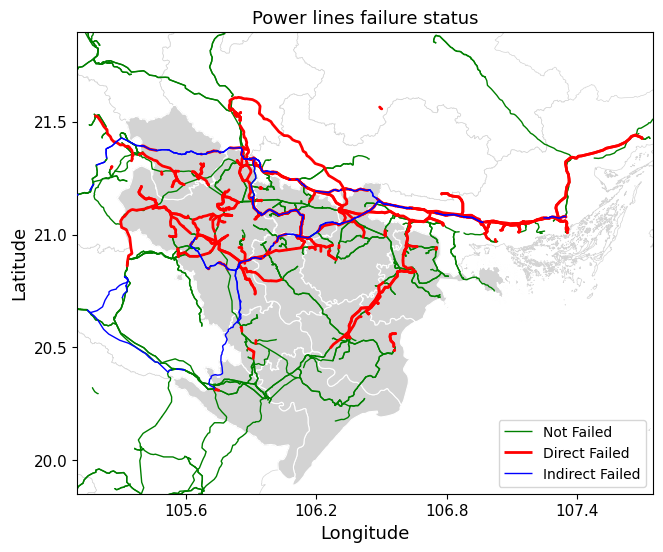

In [ ]:
# def plot_lines_based_on_failures(lines_gdf_sim, failed_lines_records, num_iterations=2):
#     # 遍历所有 fail_iter_ 列
#     for i in range(0, num_iterations):  # 从 fail_iter_1 到 fail_iter_num_iterations
#         fail_iter_column = f'fail_iter_{i+1}'
#         impact_column = f'impact_{i+1}'

#         lines_gdf_sim[impact_column] = 'Not Failed'

#         # 标记为 Failed（红色）：fail_iter_X == 1
#         lines_gdf_sim.loc[lines_gdf_sim[fail_iter_column] == 1, impact_column] = 'Direct Failed'

#         # 标记 'Indirect Failed'（蓝色）：在 failed_lines_records 中存在的线路，且 fail_iter_X == 0
#         for _, record in failed_lines_records.iterrows():
#             lines_gdf_sim.loc[(lines_gdf_sim['LineID'] == record['line_name']) & 
#                               (lines_gdf_sim[fail_iter_column] == 0), impact_column] = 'Indirect Failed'

#         # 标记为 Not Failed（绿色）：fail_iter_X == 0，且 LineID 不在 failed_lines_records 中
#         lines_gdf_sim.loc[(lines_gdf_sim[fail_iter_column] == 0) & 
#                           (~lines_gdf_sim['LineID'].isin(failed_lines_records['line_name'])), impact_column] = 'Not Failed'
    
#     return lines_gdf_sim

# lines_gdf_sim_update = plot_lines_based_on_failures(lines_gdf_sim, failed_lines_records, num_iterations=2)

# # 绘制线路
# fig, ax = plt.subplots(figsize=(8, 6))

# impact_column = 'impact_1'

# # 绘制绿色线路（未失败）
# green_lines = lines_gdf_sim_update[lines_gdf_sim_update[impact_column] == 'Not Failed']
# if not green_lines.empty:
#     green_lines.plot(ax=ax, color='green', linewidth=1, label='Not Failed', zorder=2)

# # 绘制红色线路（直接失败）
# red_lines = lines_gdf_sim_update[lines_gdf_sim_update[impact_column] == 'Direct Failed']
# if not red_lines.empty:
#     red_lines.plot(ax=ax, color='red', linewidth=2, label='Direct Failed', zorder=3)

# # 绘制蓝色线路（记录中失败）
# blue_lines = lines_gdf_sim_update[lines_gdf_sim_update[impact_column] == 'Indirect Failed']
# if not blue_lines.empty:
#     blue_lines.plot(ax=ax, color='blue', linewidth=1, label='Indirect Failed', zorder=4)

# # Define target regions to show on the map
# pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
# target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
# other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

# ax.set_title("Power lines failure status", fontsize=13)
# ax.set_xlim(105.1, 107.75)
# ax.set_ylim(19.85, 21.9)
# ax.set_aspect('auto')
# ax.tick_params(axis='both', which='major', labelsize=11)
# ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
# ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
# ax.set_xlabel("Longitude", fontsize=13)
# ax.set_ylabel("Latitude", fontsize=13)
# ax.legend(fontsize=13)

# target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
# other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)


# ax.legend(loc='lower right')

# # 显示图形
# plt.show()

In [17]:
lines_gdf_sim_update = plot_lines_based_on_failures(lines_gdf_sim, failed_lines_records, gdf_type='line', num_iterations=2)
nodes_gdf_sim_update = plot_lines_based_on_failures(nodes_gdf_sim, failed_buses_records, gdf_type='node', num_iterations=2)

In [33]:
lines_gdf_sim_update["Length"].sum()

46689.934888214484

In [34]:
lines_gdf_sim_update.length.sum()

C:\Users\mye500\AppData\Local\Temp\ipykernel_22216\3750389766.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lines_gdf_sim_update.length.sum()


358.08128971715234

In [69]:
def analyze_failure_impact(lines_gdf, nodes_gdf, impact_cols):
    summary_records = []

    lines_gdf.to_crs(epsg=4326)

    total_line_length = lines_gdf["Length"].sum()  # ["Length"]
    total_node_count = nodes_gdf.shape[0]
    print("Total line length: ", total_line_length)
    print("Total node count: ", total_node_count)

    for col in impact_cols:
        if col not in lines_gdf.columns or col not in nodes_gdf.columns:
            continue

        # Line failure lengths
        direct_lines = lines_gdf[lines_gdf[col] == "Direct Failed"]
        indirect_lines = lines_gdf[lines_gdf[col] == "Indirect Failed"]

        direct_len = direct_lines["Length"].sum()
        indirect_len = indirect_lines["Length"].sum()

        # Node failure counts
        direct_nodes = nodes_gdf[nodes_gdf[col] == "Direct Failed"]
        indirect_nodes = nodes_gdf[nodes_gdf[col] == "Indirect Failed"]

        direct_node_count = len(direct_nodes)
        indirect_node_count = len(indirect_nodes)

        summary_records.append({
            "impact_column": col,
            "direct_line_length": direct_len,
            "indirect_line_length": indirect_len,
            "direct_line_ratio": direct_len / total_line_length * 100,
            "indirect_line_ratio": indirect_len / total_line_length * 100,
            "direct_node_count": direct_node_count,
            "indirect_node_count": indirect_node_count,
            "direct_node_ratio": direct_node_count / total_node_count * 100,
            "indirect_node_ratio": indirect_node_count / total_node_count * 100
        })

    return pd.DataFrame(summary_records)

In [70]:
nodes_gdf_sim_update["impact_1"].unique

<bound method Series.unique of 0            Not Failed
1            Not Failed
2            Not Failed
3            Not Failed
4            Not Failed
5            Not Failed
6            Not Failed
7            Not Failed
8            Not Failed
9            Not Failed
10           Not Failed
11           Not Failed
12           Not Failed
13           Not Failed
14           Not Failed
15           Not Failed
16           Not Failed
17           Not Failed
18           Not Failed
19           Not Failed
20           Not Failed
21           Not Failed
22           Not Failed
23           Not Failed
24           Not Failed
25           Not Failed
26           Not Failed
27           Not Failed
28           Not Failed
29           Not Failed
30           Not Failed
31           Not Failed
32           Not Failed
33           Not Failed
34           Not Failed
35           Not Failed
36           Not Failed
37           Not Failed
38           Not Failed
39           Not Failed
40       

In [71]:
impact_cols = [col for col in lines_gdf_sim_update.columns if col.startswith("impact_")]
summary_records = analyze_failure_impact(lines_gdf_sim_update, nodes_gdf_sim_update, impact_cols)

Total line length:  46689.934888214484
Total node count:  3692


In [72]:
summary_records

,impact_column,direct_line_length,indirect_line_length,direct_line_ratio,indirect_line_ratio,direct_node_count,indirect_node_count,direct_node_ratio,indirect_node_ratio
0,impact_1,2576.203451,1033.322139,5.517685,2.213158,253,19,6.852654,0.514626
1,impact_2,2674.990561,1022.992343,5.729266,2.191034,253,19,6.852654,0.514626


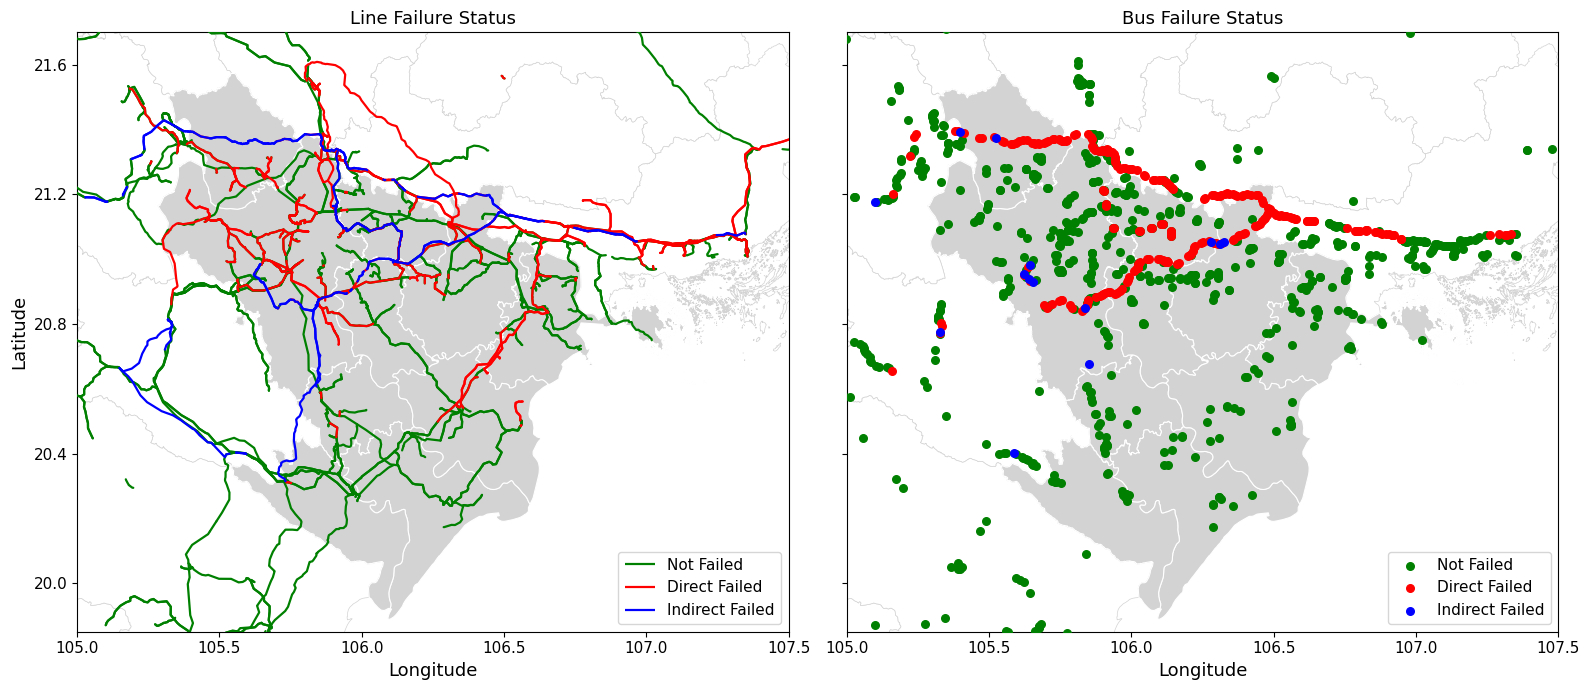

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))  # 两列并排子图

# Define target regions to show on the map
pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

# ========== 左图：绘制线路 ==========
ax = axes[0]
impact_column = 'impact_1'

status_colors = {
    'Not Failed': 'green',
    'Direct Failed': 'red',
    'Indirect Failed': 'blue'
}

for status, color in status_colors.items():
    subset = lines_gdf_sim_update[lines_gdf_sim_update[impact_column] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=1.6, label=status, zorder=3)

# 背景图层
target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)

ax.set_title("Line Failure Status", fontsize=13)
ax.set_xlim(105, 107.5)
ax.set_ylim(19.85, 21.7)
ax.set_aspect('auto')
ax.tick_params(axis='both', which='major', labelsize=11)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.legend(loc='lower right', fontsize=11)

# ========== 右图：绘制节点 ==========
ax = axes[1]

for status, color in status_colors.items():
    subset = nodes_gdf_sim_update[nodes_gdf_sim_update[impact_column] == status]
    if not subset.empty:
        subset.plot(ax=ax, color=color, markersize=30, label=status, zorder=3)

# 背景图层
target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)

ax.set_title("Bus Failure Status", fontsize=13)
ax.set_xlim(105, 107.5)
ax.set_ylim(19.85, 21.7)
ax.set_aspect('auto')
ax.tick_params(axis='both', which='major', labelsize=11)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(labelleft=False)
ax.set_xlabel("Longitude", fontsize=13)
# ax.set_ylabel("Latitude", fontsize=13)
ax.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()


In [147]:
def prepare_loads_map(load_status_df, loads_gdf):
    loads_gdf = loads_gdf.copy()
    load_status_df = load_status_df.copy()

    loads_gdf["osmid"] = pd.to_numeric(loads_gdf["osmid"], errors="coerce")
    load_status_df = load_status_df.rename(columns={"load_id": "osmid"})
    load_status_df["osmid"] = pd.to_numeric(load_status_df["osmid"], errors="coerce")

    # Compute average, min, and max served ratio per osmid per frac
    avg_status = (
        load_status_df.groupby(["osmid", "fail_iter"])["served"]
        .agg(served_ratio_mean="mean", served_ratio_min="min", served_ratio_max="max")
        .reset_index()
    )

    loads_gdf = loads_gdf.merge(avg_status, on="osmid", how="left")

    return loads_gdf


def plot_served_ratio_maps(loads_gdf, fig_path=None, basemap=None):
    loads_gdf = loads_gdf.to_crs("EPSG:4326")
    basemap = basemap.to_crs("EPSG:4326")

    pcode_list = ['VN106','VN111','VN101','VN107','VN103','VN109','VN113','VN117','VN115','VN104']
    target_regions = basemap[basemap["ADM1_PCODE"].isin(pcode_list)]
    other_regions = basemap[~basemap["ADM1_PCODE"].isin(pcode_list)]

    unique_iters = loads_gdf["fail_iter"].dropna().unique()

    vmin = loads_gdf["served_ratio_mean"].min()
    vmax = loads_gdf["served_ratio_mean"].max()
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.colormaps.get_cmap("RdYlGn")

    os.makedirs(fig_path, exist_ok=True)

    for iter_label in unique_iters:
        iter_data = loads_gdf[loads_gdf["fail_iter"] == iter_label]

        fig, ax = plt.subplots(figsize=(8, 7))

        ax.set_xlabel("Longitude", fontsize=14)
        ax.set_ylabel("Latitude", fontsize=14)
        ax.set_xlim(105, 107.25)
        ax.set_ylim(19.75, 21.75)
        ax.set_aspect('auto')
        ax.tick_params(axis='both', which='major', labelsize=12)

        target_regions.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.8, zorder=1)
        other_regions.plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5, zorder=0)
        iter_data.plot(ax=ax, column="served_ratio_mean", cmap=cmap, norm=norm, markersize=100, legend=False, zorder=2)

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []
        cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.042)
        cbar.set_label("Served load ratio", fontsize=14)

        if fig_path:
            output_path = f"{fig_path}/served_ratio_map_{iter_label}.png"
            plt.savefig(output_path, dpi=600, bbox_inches="tight")
        plt.show(fig)


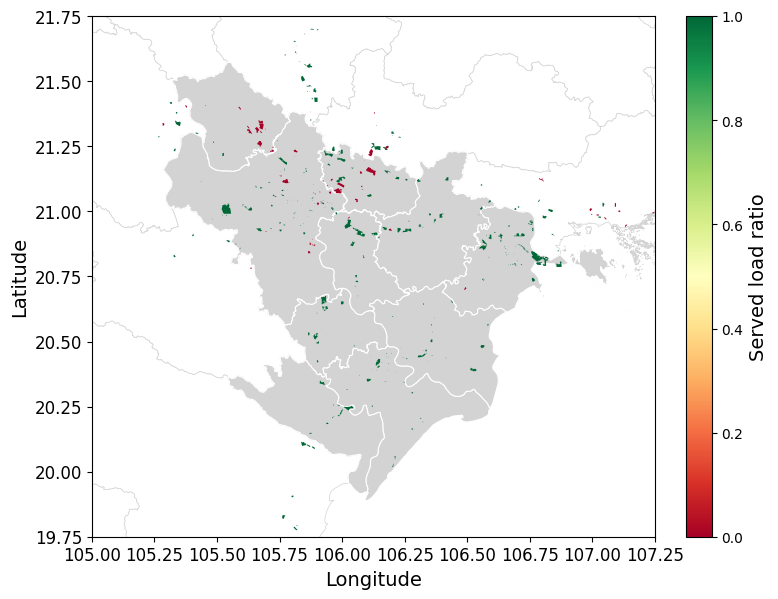

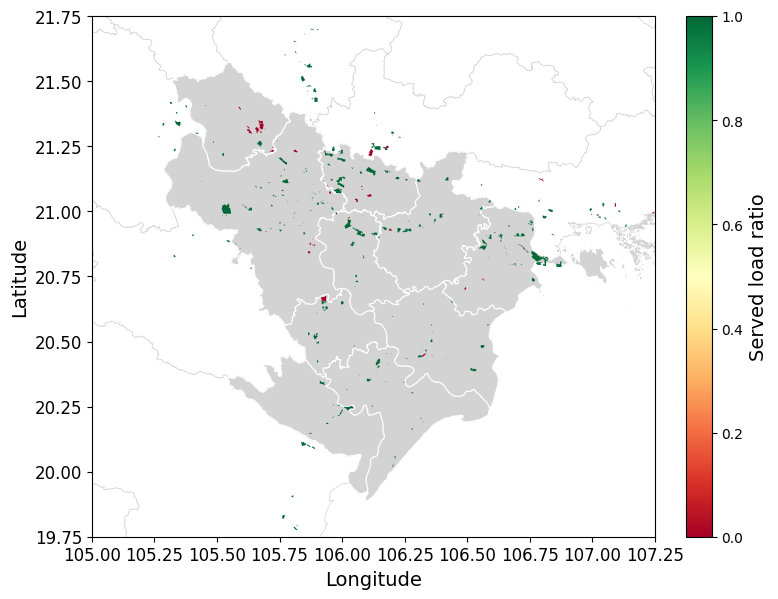

In [148]:
loads_gdf_update = prepare_loads_map(load_status_records, loads_gdf)
plot_served_ratio_maps(loads_gdf_update, fig_path='../figures/hazard_figures', basemap=basemap)

In [62]:
# 供电比例变化折线图
# 展示：不同失效迭代下，系统中有多少电负载（MW）仍然得到供电。

def plot_served_ratio_over_iterations(results):
    iters = list(results.keys())
    ratios = [results[it]['served_ratio'] for it in iters]

    plt.figure(figsize=(8, 5))
    plt.plot(iters, ratios, marker='o', color='red')
    plt.xticks(rotation=45)
    plt.ylim(0, 1.05)
    plt.ylabel('Served Load Ratio')
    plt.xlabel('Failure Iteration')
    plt.title('Load served ratio over simulated failures')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_served_ratio_over_iterations(results)

KeyError: 'served_ratio'